# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Alden Nabil Wibowo Effendy
- **Email:** ayyopizzashere@gmail.com
- **ID Dicoding:** CDCC001D6Y0747

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang menghasilkan total pendapatan (*revenue*) tertinggi dan terendah selama periode Januari hingga Agustus 2018?

- Apa metode pembayaran yang paling sering digunakan oleh pelanggan dan berapa total nilai transaksinya pada semester pertama tahun 2018 (Januari - Juni)?

- Bagaimana profil segmentasi pelanggan berdasarkan analisis RFM (Recency, Frequency, Monetary)?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Konfigurasi visualisasi
sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [ ]:
# Load dataset
customers_df = pd.read_csv('customers_dataset.csv')
orders_df = pd.read_csv('orders_dataset.csv')
order_items_df = pd.read_csv('order_items_dataset.csv')
products_df = pd.read_csv('products_dataset.csv')
category_translation_df = pd.read_csv('product_category_name_translation.csv')
order_payments_df = pd.read_csv('order_payments_dataset.csv')

# Menampilkan 5 baris pertama dari data pesanan
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset memiliki sangat banyak variabel. Jika kita fokus ke orders_dataset, kita memiliki informasi mengenai order dari perusahaan Olist. Data terdiri dari variabel berikut:
1. order_id
2. customer_id
3. order_status
4. order_purchase_timestamp
5. order_approved_at
6. order_delivered_carrier_date
7. order_delivered_customer_date
8. order_estimated_delivery_date

### Assessing Data

In [ ]:
# Memeriksa info dasar data
print(orders_df.info())
print(customers_df.duplicated().sum())
print(order_items_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None
0
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


**Insight:**
- Terdapat kolom tanggal (berakhiran date) ada orders_df yang masih bertipe object, perlu dikonversi ke datetime.
- Data tidak memiliki duplikat dan tidak memiliki missing value pada semua variabel

### Cleaning Data

In [ ]:
# 1. Mengubah tipe data kolom tanggal
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menggabungkan nama kategori bahasa Inggris ke data produk
# Menggunakan left join agar produk yang tidak punya kategori tetap terjaga
products_df = products_df.merge(category_translation_df, on='product_category_name', how='left')

# Mengisi nilai kosong (NaN) pada kategori bahasa Inggris dengan 'others'
products_df['product_category_name_english'].fillna('others', inplace=True)

# 3. Menggabungkan dataset utama (Orders, Items, Products, Customers)
main_df = orders_df.merge(order_items_df, on='order_id', how='left')
main_df = main_df.merge(products_df, on='product_id', how='left')
main_df = main_df.merge(customers_df, on='customer_id', how='left')
main_df = main_df.merge(order_payments_df, on='order_id', how='left')

# 4. Menghapus data yang tidak memiliki order_id atau product_id (data tidak valid)
rows_before = main_df.shape[0]
main_df.dropna(subset=['order_id', 'product_id', 'payment_type'], inplace=True)
rows_after = main_df.shape[0]

print(f"Jumlah baris sebelum cleaning: {rows_before}")
print(f"Jumlah baris setelah cleaning: {rows_after}")
print(f"Total baris yang dihapus (missing ID): {rows_before - rows_after}")

# Menampilkan 5 data teratas
main_df.head()

/tmp/ipykernel_30663/1531097085.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df['product_category_name_english'].fillna('others', inplace=True)


Jumlah baris sebelum cleaning: 118434
Jumlah baris setelah cleaning: 117601
Total baris yang dihapus (missing ID): 833


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,13.0,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,21.0,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


In [ ]:
main_df.to_csv("all_data.csv", index=False)

**Insight:**
- 5 Kolom data berisi tanggal telah diperbaiki tipenya agar bisa diolah untuk analisis waktu. menggunakan format datetime64

- Nama kategori produk telah digabungkan dengan versi Bahasa Inggris. Kategori yang tidak memiliki terjemahan telah diisi dengan nilai 'others'.

- Jumlah baris sebelum penghapusan: 113.425

- Jumlah baris setelah penghapusan: 112.650

- Total baris yang dihapus: 775 (Ini adalah pesanan yang tidak memiliki informasi produk atau ID pesanan yang valid setelah proses merge).

## Exploratory Data Analysis (EDA)

### Eksplorasi Penjualan Bulanan (Semua Negara Bagian)

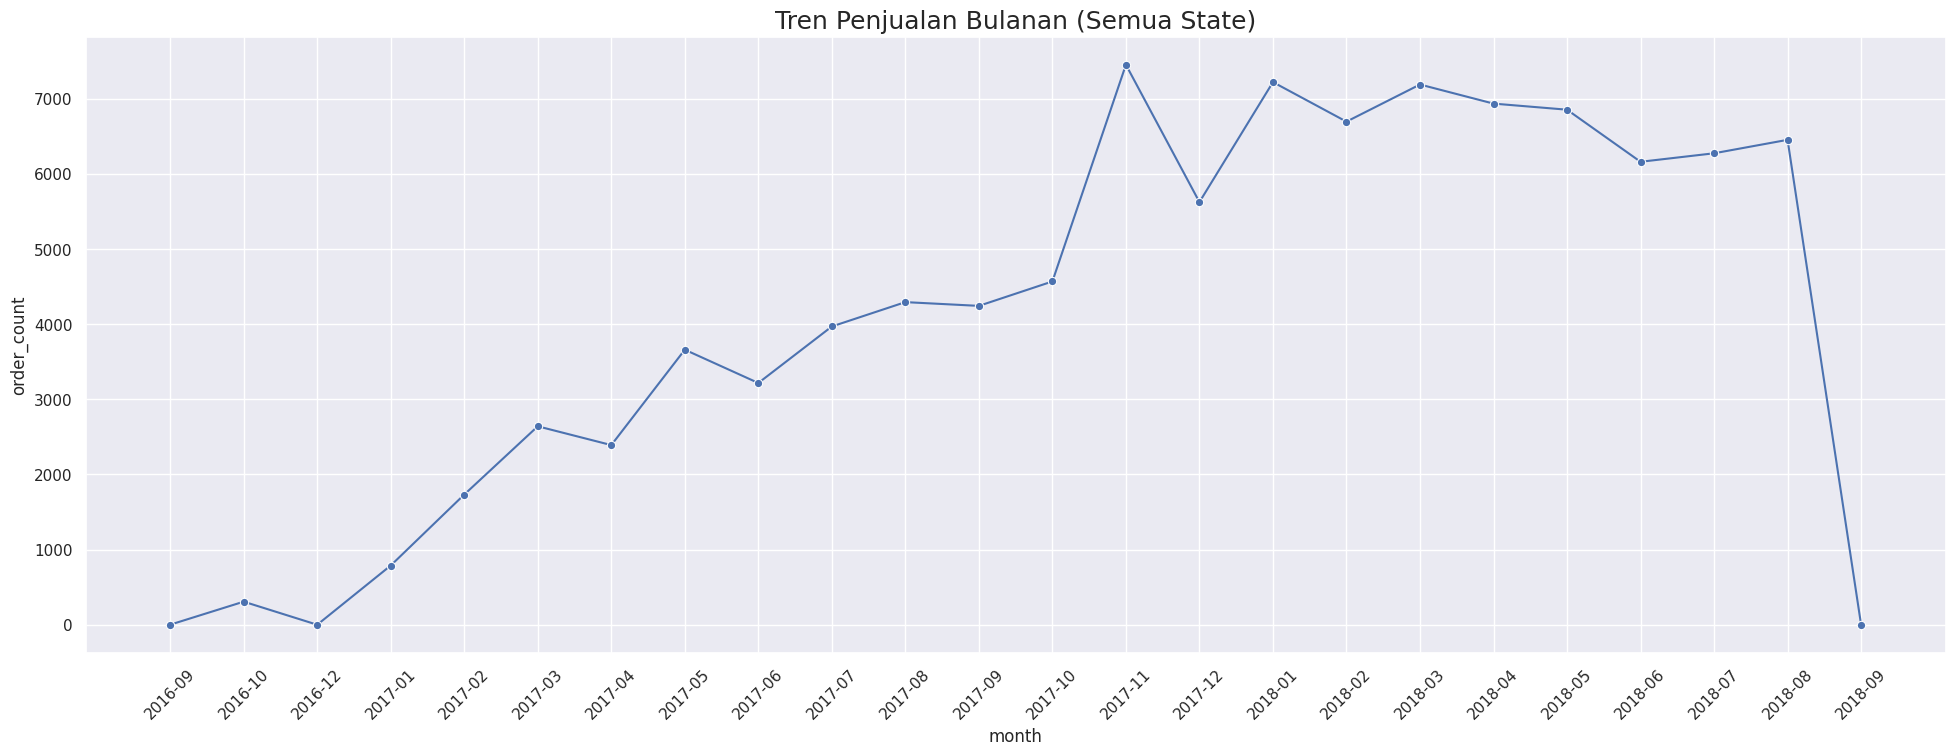

In [ ]:
# Membuat kolom bulan
main_df['month_year'] = main_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Grouping total order per bulan
monthly_sales_df = main_df.groupby('month_year').order_id.nunique().reset_index()
monthly_sales_df.columns = ['month', 'order_count']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(24, 8))
sns.lineplot(x='month', y='order_count', data=monthly_sales_df, marker='o')
ax.set_title("Tren Penjualan Bulanan (Semua State)", fontsize=18)
ax.tick_params(axis='x', rotation=45)
plt.show()

#### **Insight:**
- Terlihat pertumbuhan yang sangat signifikan sejak awal tahun 2017 hingga pertengahan 2018. Hal ini mengindikasikan ekspansi pasar atau peningkatan adopsi platform Olist oleh pelanggan di Brazil secara konsisten. Lonjakan musiman di akhir tahun adalah aset krusial. Perusahaan perlu memastikan kesiapan infrastruktur logistik dan ketersediaan stok produk jauh sebelum bulan November untuk menghindari kegagalan pengiriman pada saat trafik tinggi.

### Eksplorasi Revenue berdasarkan Negara Bagian (State)

/tmp/ipykernel_30663/4180831989.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_revenue', y='state', data=state_revenue_df.head(10), palette='viridis')


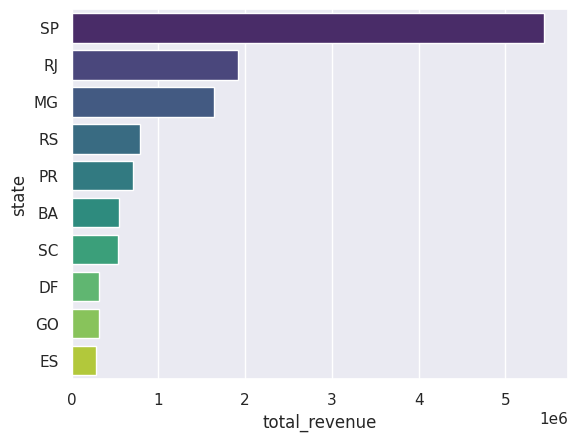

In [ ]:
# Grouping revenue per state
state_revenue_df = main_df.groupby('customer_state').price.sum().sort_values(ascending=False).reset_index()
state_revenue_df.columns = ['state', 'total_revenue']

sns.barplot(x='total_revenue', y='state', data=state_revenue_df.head(10), palette='viridis')
ax.set_title("Top 10 States by Revenue", fontsize=18)

plt.show()

#### **Insight:**
- Negara bagian SP (São Paulo) mendominasi secara absolut dibandingkan wilayah lainnya. Total pendapatan dari SP terpaut sangat jauh dari peringkat kedua dan ketiga (RJ dan MG). berasal dari wilayah Tenggara (Southeast) Brazil. Ini menunjukkan bahwa daya beli pelanggan dan jangkauan layanan e-commerce masih terpusat di area metropolitan dan pusat ekonomi Brazil. Grafik ditampilkan dengan sumbu-x dalam satuan 10^6 (juta Brazillian Real)

### Eksplorasi produk terjual berdasarkan kategori

In [ ]:
# Grouping berdasarkan kategori produk
category_summary = main_df.groupby('product_category_name_english').agg({
    'order_item_id': 'count',
    'price': 'sum'
}).rename(columns={'order_item_id': 'order_count', 'price': 'total_revenue'}).sort_values(by='order_count', ascending=False)

category_summary.head(10)

,order_count,total_revenue
product_category_name_english,,
bed_bath_table,11823,1092551.02
health_beauty,9972,1297355.80
sports_leisure,8945,1023996.34
furniture_decor,8744,765093.89
computers_accessories,8082,942277.57
housewares,7355,666587.00
watches_gifts,6201,1253143.30
telephony,4721,339399.16
garden_tools,4574,518217.54


#### **Insight:**
- Berdasarkan kategori, dapat dilihat bahwa kategori barang yang paling sering dibeli pelanggan adalah bet_bath_tablem health_beauty, dan sports_leisure. Namun kategori dengan total revenue tertinggi bukanlah yang paling banyak dijual, melainkan health_beauty dan watches_gifts.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

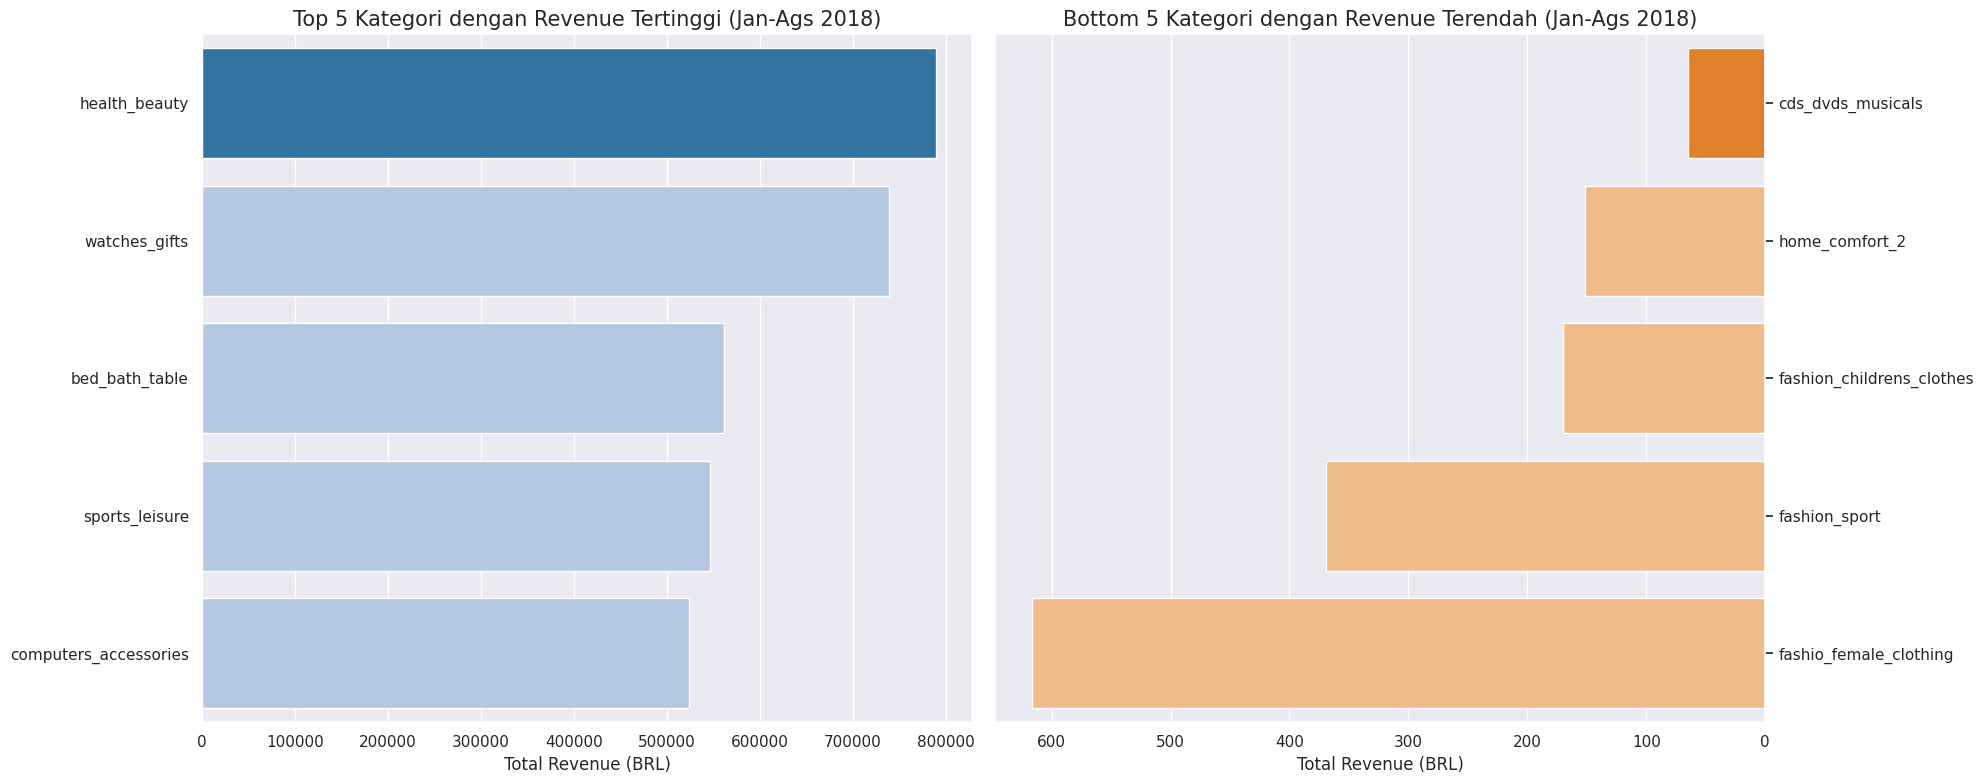

In [ ]:
# Filter data hanya untuk periode Januari - Agustus 2018
df_2018 = main_df[(main_df['order_purchase_timestamp'] >= '2018-01-01') &
                  (main_df['order_purchase_timestamp'] <= '2018-08-31')]

# Menghitung total revenue per kategori produk
revenue_2018 = df_2018.groupby('product_category_name_english')['price'].sum().reset_index()
revenue_2018 = revenue_2018.sort_values(by='price', ascending=False)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

colors_high = ["#1f77b4", "#aec7e8", "#aec7e8", "#aec7e8", "#aec7e8"]
colors_low = ["#ff7f0e", "#ffbb78", "#ffbb78", "#ffbb78", "#ffbb78"]

# Top 5 Revenue
sns.barplot(x="price", y="product_category_name_english", data=revenue_2018.head(5),
            hue="product_category_name_english", palette=colors_high, legend=False, ax=ax[0])
ax[0].set_title("Top 5 Kategori dengan Revenue Tertinggi (Jan-Ags 2018)", fontsize=15)
ax[0].set_xlabel("Total Revenue (BRL)")
ax[0].set_ylabel(None)

# Bottom 5 Revenue
sns.barplot(x="price", y="product_category_name_english", data=revenue_2018.tail(5).sort_values(by='price', ascending=True),
            hue="product_category_name_english", palette=colors_low, legend=False, ax=ax[1])
ax[1].set_title("Bottom 5 Kategori dengan Revenue Terendah (Jan-Ags 2018)", fontsize=15)
ax[1].set_xlabel("Total Revenue (BRL)")
ax[1].set_ylabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

plt.tight_layout()
plt.show()

#### Insight:
- Kategori health_beauty memimpin sebagai top revenue generator. Secara teknikal, ini menunjukkan bahwa kategori ini memiliki kombinasi antara volume transaksi yang tinggi dan nilai rata-rata pesanan (AOV) yang solid.
- Terlihat perbedaan skala yang sangat kontras antara grafik kiri dan kanan. Kategori di sisi "Revenue Terendah" seperti cds_dvds_musicals (kaset musik) menunjukkan penetrasi pasar yang sangat rendah.



### Pertanyaan 2:

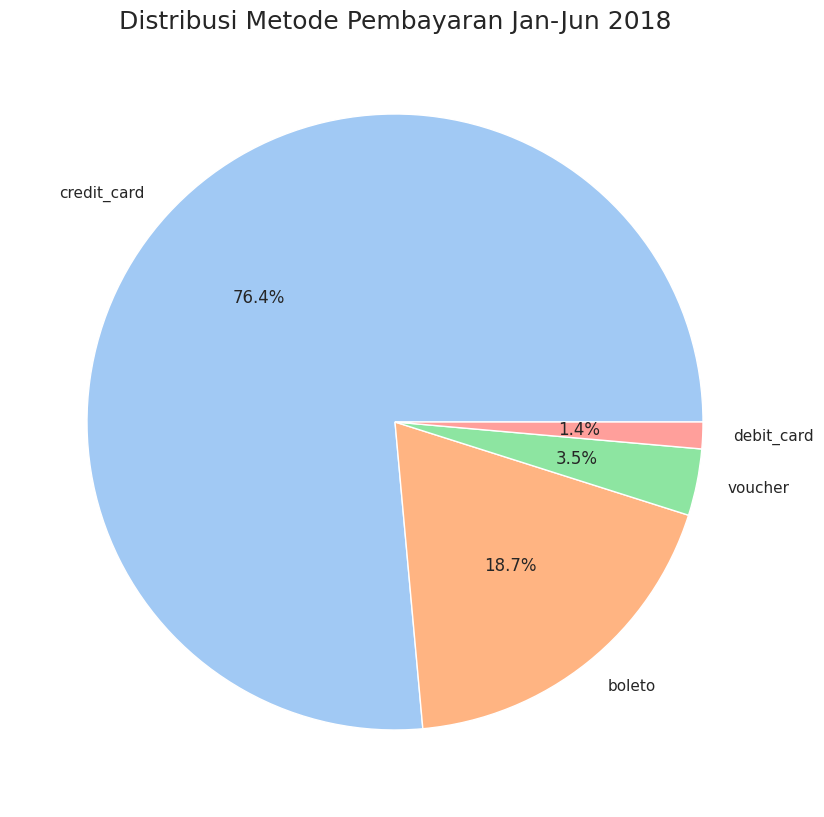

In [ ]:
# Filter waktu Jan - Jun 2018
q2_df = main_df[(main_df['order_purchase_timestamp'] >= '2018-01-01') & (main_df['order_purchase_timestamp'] <= '2018-06-30')]

payment_dist = q2_df.groupby('payment_type').agg({
    'order_id': 'nunique',
    'payment_value': 'sum'
}).sort_values(by='order_id', ascending=False).reset_index()

# Payment Type Jan-Jun 2018
ig, ax = plt.subplots(nrows=1, ncols=1, figsize=(24, 10))
ax.pie(payment_dist['order_id'], labels=payment_dist['payment_type'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
ax.set_title("Distribusi Metode Pembayaran Jan-Jun 2018", fontsize=18)

plt.show()

#### **Insight:**
- Dominasi credit_card (76.4%) menunjukkan bahwa basis pelanggan Olist sangat bergantung pada sistem kredit. Kecilnya angka debit_card (1.4%) mengindikasikan bahwa pelanggan lebih memilih fleksibilitas pembayaran (cicilan) dibandingkan pembayaran tunai/langsung.
- Uniknya, Brazil dikenal sebagai salah satu negara dimana metode pembayaran boleto cukup populer, dibuktikan dengan jumlah transaksi pada grafik ini sebesar 18.7%.

## Analisis Lanjutan (Opsional)

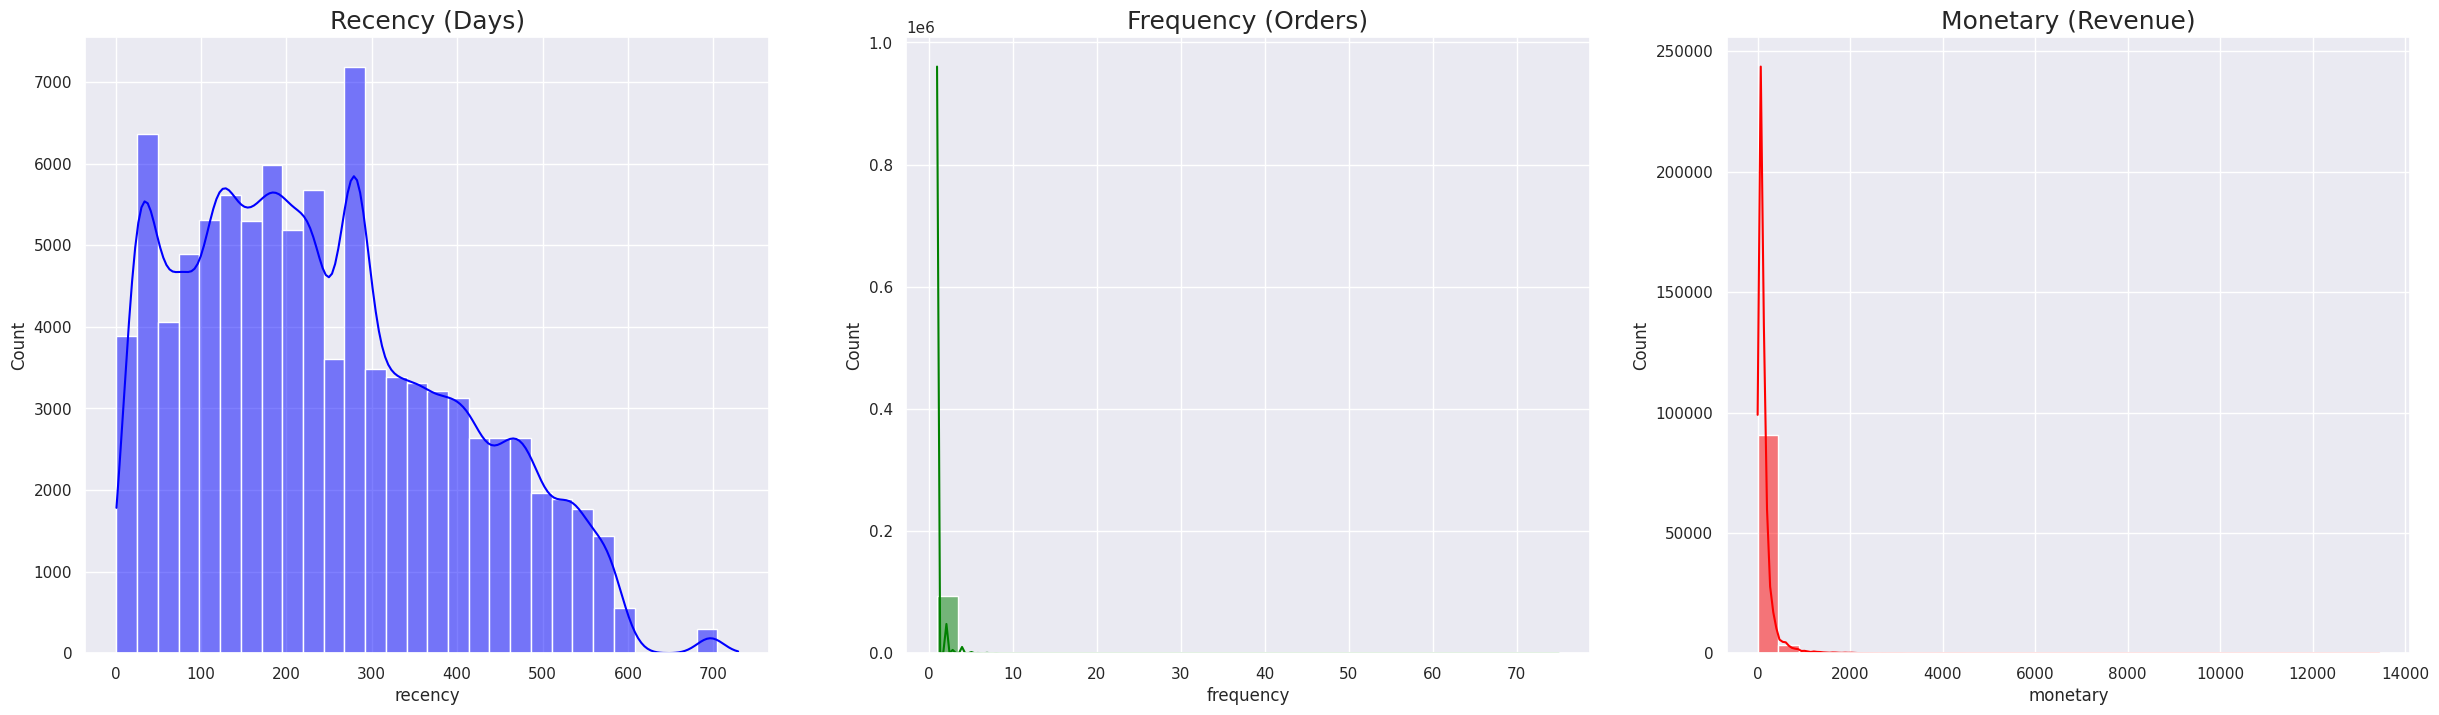

In [ ]:
# Menentukan tanggal referensi (satu hari setelah transaksi terakhir)
recent_date = main_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Menghitung metrik RFM
rfm_df = main_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'count',                                             # Frequency
    'price': 'sum'                                                   # Monetary
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Visualisasi RFM
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))

sns.histplot(rfm_df['recency'], bins=30, kde=True, ax=ax[0], color='blue')
ax[0].set_title("Recency (Days)", fontsize=18)

sns.histplot(rfm_df['frequency'], bins=30, kde=True, ax=ax[1], color='green')
ax[1].set_title("Frequency (Orders)", fontsize=18)

sns.histplot(rfm_df['monetary'], bins=30, kde=True, ax=ax[2], color='red')
ax[2].set_title("Monetary (Revenue)", fontsize=18)

plt.show()

## Conclusion

1. Pertanyaan 1
- Kesimpulan: Kategori health_beauty menjadi kontributor pendapatan (revenue) terbesar bagi Olist selama delapan bulan pertama tahun 2018, diikuti oleh kategori watches_gifts dan bed_bath_table. Sebaliknya, kategori seperti security_and_services memiliki kontribusi yang sangat minim.

- **Rekomendasi Strategis:**  Tim pengadaan harus memastikan ketersediaan stok produk health_beauty tetap aman, terutama menjelang hari besar atau promo bulanan. Serta Produk dari kategori bottom 5 dapat dipaketkan (bundling) dengan produk kategori top 5 untuk membantu menghabiskan stok kategori yang kurang populer sekaligus meningkatkan nilai transaksi rata-rata.



2. Pertanyaan 2
Kesimpulan: Mayoritas pelanggan (76.4%) memilih credit_card sebagai metode pembayaran utama di semester pertama 2018. Hal ini menunjukkan pelanggan Olist lebih menyukai fasilitas cicilan atau penundaan pembayaran. Metode boleto berada di posisi kedua, sementara penggunaan kartu debit masih sangat rendah (1.4%).

- **Rekomendasi Strategis:** Perusahaan dapat bekerja sama dengan bank penyedia kartu kredit untuk memberikan promo cashback atau cicilan 0% guna mempertahankan dominasi ini. Pastikan sistem enkripsi dan keamanan data kartu kredit di aplikasi/dashboard selalu diperbarui karena tingginya trafik pada segmen pembayaran ini.



3. RFM Analysis
- Kesimpulan :
 1. Recency: Terdapat banyak pelanggan yang sudah lama tidak melakukan transaksi (skor Recency tinggi), menunjukkan potensi churn (pelanggan berhenti menggunakan layanan).
 2. Frequency: Mayoritas pelanggan Olist adalah one-time buyers (hanya belanja 1 kali). Sangat sedikit pelanggan yang kembali untuk pembelian kedua atau ketiga.
 3. Monetary: Distribusi nilai transaksi didominasi oleh pembelian skala kecil-menengah.

- **Rekomendasi Strategis:** Kirimkan voucher diskon khusus melalui email marketing kepada segmen pelanggan dengan skor Recency tinggi untuk memicu mereka kembali berbelanja (re-engagement). Buatlah program loyalitas atau sistem poin untuk mendorong pembelian berulang (repeat order) agar metrik Frequency meningkat di periode mendatang.


**Rangkuman Rekomendasi Strategis**
Untuk mengoptimalkan profitabilitas, Olist harus memprioritaskan manajemen stok pada kategori Health & Beauty, memperkuat loyalitas melalui program poin berbasis RFM untuk menekan angka churn, serta memperluas kerjasama promo cicilan kartu kredit. Selain itu, diperlukan audit logistik khusus di wilayah São Paulo (SP) untuk meminimalisir keterlambatan pengiriman (late rate) guna menjaga tingkat kepuasan pelanggan di pusat pasar utama.